In [4]:
import pandas as pd, yfinance as yf, requests, matplotlib.pyplot as plt, numpy as np
from bs4 import BeautifulSoup
from io import StringIO

In [22]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

# Extracting TESLA Stock Data using yfinance

In [24]:
tesla_tickr = yf.Ticker('TSLA')

tesla_tickr.info   #Checking the ticker info to make sure the data actually belongs to TESLA

tesla_stock_data = tesla_tickr.history(period ='max')   #Extracting the stock data
tesla_stock_data.reset_index(inplace=True)   # Reset the index of the stock dataframe
tesla_stock_data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0
...,...,...,...,...,...,...,...,...
3905,2026-01-07 00:00:00-05:00,435.899994,438.369995,431.290009,431.410004,59828800,0.0,0.0
3906,2026-01-08 00:00:00-05:00,427.890015,436.890015,424.369995,435.799988,57041100,0.0,0.0
3907,2026-01-09 00:00:00-05:00,435.950012,449.049988,430.390015,445.010010,67331500,0.0,0.0
3908,2026-01-12 00:00:00-05:00,441.230011,454.299988,438.000000,448.959991,61451900,0.0,0.0


In [25]:
tesla_stock_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


# Extracting TESLA revenue data using Webscraping

In [39]:
tesla_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'
html_data = requests.get(tesla_url).text #Extract the html data from the webpage


In [27]:
from io import StringIO

soup = BeautifulSoup(html_data,'html.parser')  #parsing the htmk using BeautifulSoup
tables = soup.find_all('table')  #Extracting the html tables using table tag
revenue_table = tables[1]   #Extracting the revenue table

tesla_revenue = pd.read_html(StringIO(str(revenue_table)))[0]

tesla_revenue.columns=['Date','Revenue']

tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


In [28]:
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(r',|\$',"",regex=True)
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


In [29]:
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue']!=""]
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


# Extract GME Stock data using yfinance

In [46]:
gme_ticker = yf.Ticker('GME')    #Exctracting the GameStop stock data using yfinance ticker function

In [47]:
gme_ticker.info  #checking the extracted ticker object to make sure the data belongs to GameStop
gme_data = gme_ticker.history(period='max')  #Extracting GME Stock data since the beginning
gme_data.reset_index(inplace=True)    #Resetting the index of the stock dataframe
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603296,1.662209,6892800,0.0,0.0


# Extracting GME Revenue data using Webscraping

In [48]:
GME_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'

GME_hmtl = requests.get(GME_url).text   #Extracting the html content from the webpage

GME_soup = BeautifulSoup(GME_hmtl,'html.parser')   #parsing the html content using BeautifulSoup

GME_tables = GME_soup.find_all('table')   #Extracting the tables from the html content

gme_revenue = pd.read_html(StringIO(str(GME_tables[1])))[0]  #Creating the Stock dataframe using pandas read_html

gme_revenue.columns = ['Date','Revenue']   #Updating the Columns names
gme_revenue.head()

,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [49]:
gme_revenue['Revenue']=gme_revenue['Revenue'].str.replace(r',|\$',"",regex=True)  # removing the "," and "$" from the revenue column

gme_revenue.dropna(inplace=True)  #Drop rows with null values
gme_revenue = gme_revenue[gme_revenue['Revenue']!=""]  #Drop rows where Revenue is empty
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


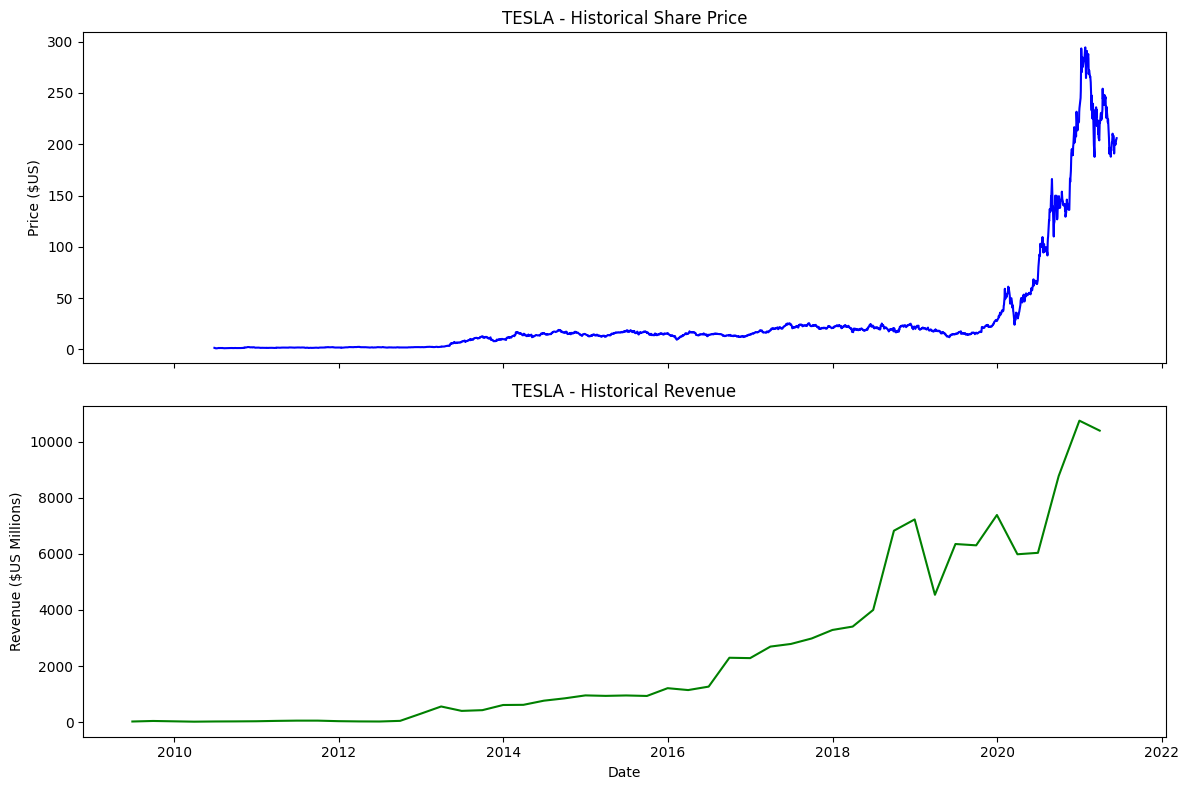

In [50]:
make_graph(tesla_stock_data,tesla_revenue,'TESLA')

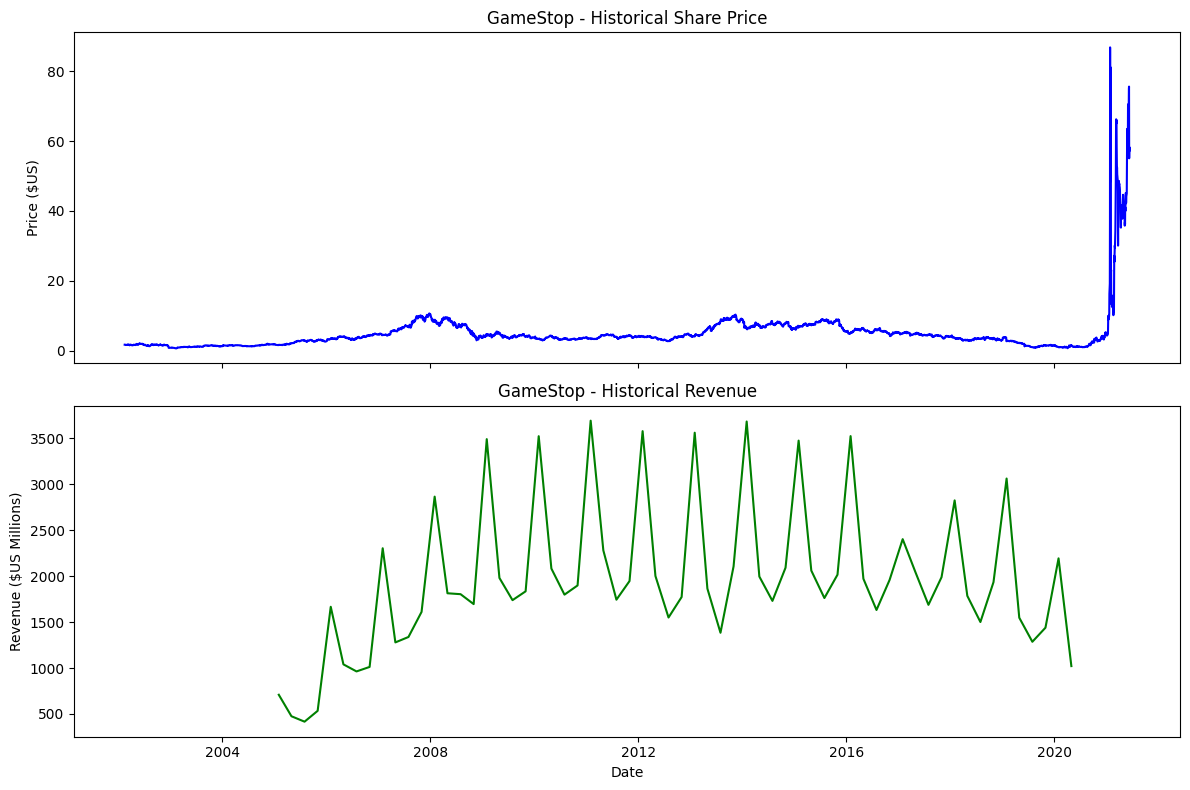

In [51]:
make_graph(gme_data,gme_revenue,'GameStop')

# Author

Sreekanth Reddy Agile